In [37]:
from astropy.time import Time
from astropy.coordinates import EarthLocation
from astropy import units as u
_altaz_cache = {}
t = Time("2026-02-21 02:00:00")  # UTC
loc = EarthLocation(lat=42.28*u.deg, lon=-83.74*u.deg)  # Ann Arbor

print(t)
print(loc)

2026-02-21 02:00:00.000
(515339.14953132, -4697951.355956336, 4268665.649310409) m


In [2]:
from astropy.coordinates import SkyCoord, AltAz
import numpy as np

# Sirius (天狼星) RA/Dec
sirius = SkyCoord(ra=101.287*u.deg, dec=-16.716*u.deg, frame='icrs')

altaz = sirius.transform_to(AltAz(obstime=t, location=loc))

print("Altitude:", altaz.alt.deg)
print("Azimuth:", altaz.az.deg)

Altitude: 30.840375005183436
Azimuth: 175.19059361043907


In [3]:
import pandas as pd

data = [
    ["Sirius", 101.287, -16.716, -1.46],
    ["Canopus", 95.987, -52.695, -0.74],
    ["Arcturus", 213.915, 19.182, -0.05],
    ["Vega", 279.234, 38.783, 0.03],
    ["Capella", 79.172, 45.998, 0.08],
    ["Rigel", 78.634, -8.202, 0.12],
    ["Procyon", 114.825, 5.225, 0.38],
    ["Betelgeuse", 88.793, 7.407, 0.42],
    ["Achernar", 24.428, -57.236, 0.46],
    ["Hadar", 210.955, -60.373, 0.61],
]

df = pd.DataFrame(data, columns=["name", "ra_deg", "dec_deg", "mag"])
df.to_csv("stars.csv", index=False)


In [4]:
import pandas as pd

df = pd.read_csv("stars.csv")

coords = SkyCoord(
    ra=df["ra_deg"].values*u.deg,
    dec=df["dec_deg"].values*u.deg,
    frame="icrs"
)

altaz = coords.transform_to(AltAz(obstime=t, location=loc))

df["alt_deg"] = altaz.alt.deg
df["az_deg"] = altaz.az.deg

visible = df[df["alt_deg"] > 0].sort_values("mag")

print(visible[["name", "mag", "alt_deg", "az_deg"]].head(10))

         name   mag    alt_deg      az_deg
0      Sirius -1.46  30.840375  175.190594
4     Capella  0.08  76.850315  292.563093
5       Rigel  0.12  36.839493  202.878650
6     Procyon  0.38  49.616226  151.797030
7  Betelgeuse  0.42  54.399826  193.925503


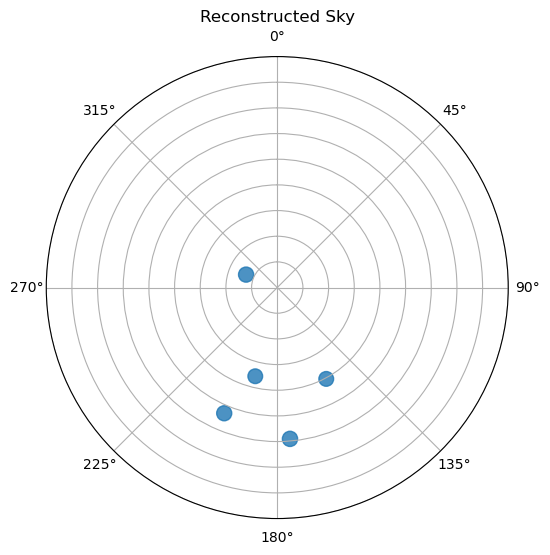

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def plot_sky(df):
    az = np.deg2rad(df["az_deg"].values)
    r = 90 - df["alt_deg"].values  # zenith at center
    mag = df["mag"].values

    # 星等映射到大小（简单版本）
    sizes = np.clip(120 - 20*mag, 5, 120)

    fig = plt.figure(figsize=(6,6))
    ax = plt.subplot(111, projection="polar")
    ax.scatter(az, r, s=sizes, alpha=0.8)
    ax.set_ylim(0, 90)
    ax.set_yticklabels([])
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_title("Reconstructed Sky")
    plt.show()

plot_sky(visible)

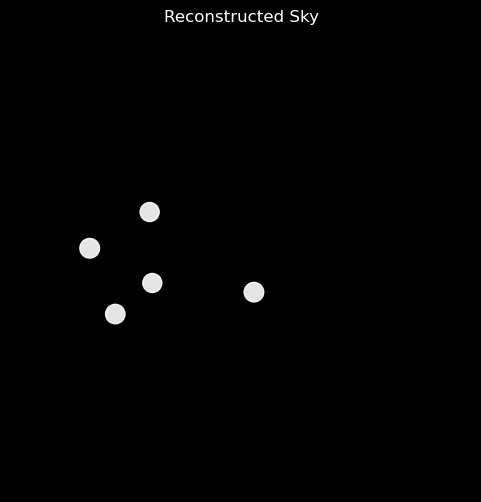

In [6]:
def plot_sky(df):
    az = np.deg2rad(df["az_deg"].values)
    r = 90 - df["alt_deg"].values
    mag = df["mag"].values

    sizes = np.clip(200 - 30*mag, 5, 200)

    fig = plt.figure(figsize=(6,6))
    ax = plt.subplot(111, projection="polar")

    # 黑色背景
    fig.patch.set_facecolor("black")
    ax.set_facecolor("black")

    ax.scatter(az, r, s=sizes, color="white", alpha=0.9)

    ax.set_ylim(0, 90)
    ax.set_yticklabels([])
    ax.set_xticklabels([])

    ax.grid(False)
    ax.set_title("Reconstructed Sky", color="white")

    plt.show()

plot_sky(visible)

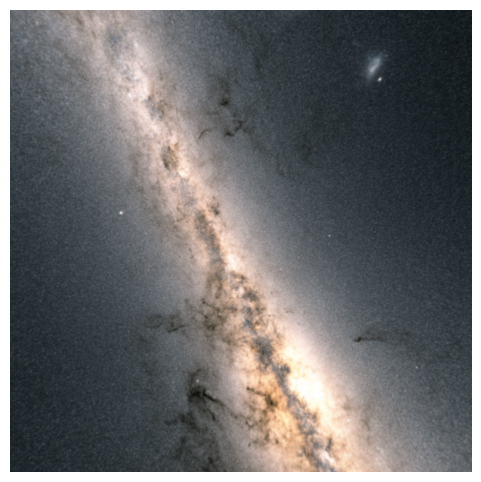

In [7]:
import numpy as np
from PIL import Image

from astropy.time import Time
from astropy import units as u
from astropy.coordinates import EarthLocation, SkyCoord, AltAz

def _bilinear_sample(img, x, y):
    """
    img: HxWx3 float array in [0,1]
    x,y: sample coords in pixel space (float), same shape
    """
    H, W = img.shape[:2]
    x0 = np.floor(x).astype(int) % W
    x1 = (x0 + 1) % W
    y0 = np.clip(np.floor(y).astype(int), 0, H-1)
    y1 = np.clip(y0 + 1, 0, H-1)

    wx = x - np.floor(x)
    wy = y - np.floor(y)

    Ia = img[y0, x0]
    Ib = img[y0, x1]
    Ic = img[y1, x0]
    Id = img[y1, x1]

    wa = (1-wx) * (1-wy)
    wb = wx * (1-wy)
    wc = (1-wx) * wy
    wd = wx * wy

    return (Ia*wa[...,None] + Ib*wb[...,None] + Ic*wc[...,None] + Id*wd[...,None])

def render_milkyway_background(
    bg_path,
    lat_deg, lon_deg, dt_iso_utc,
    center_alt_deg=45, center_az_deg=180,
    fov_deg=80, out_size=512
):
    """
    使用“银河全天贴图（Galactic 坐标 equirectangular 2:1）”裁剪出你当前视野。
    输出: out_size x out_size x 3 的RGB float数组 [0,1]
    """
    # load background image
    bg = Image.open(bg_path).convert("RGB")
    bg = np.asarray(bg).astype(np.float32) / 255.0
    H, W = bg.shape[:2]

    # observer & time
    loc = EarthLocation(lat=lat_deg*u.deg, lon=lon_deg*u.deg, height=0*u.m)
    t = Time(dt_iso_utc)  # UTC recommended

    # image plane grid (gnomonic)
    n = out_size
    fov = np.deg2rad(fov_deg)
    scale = np.tan(fov/2)
    xs = np.linspace(-scale, scale, n)
    ys = np.linspace(-scale, scale, n)
    X, Y = np.meshgrid(xs, ys)

    # ENU basis: x=East, y=North, z=Up
    alt0 = np.deg2rad(center_alt_deg)
    az0  = np.deg2rad(center_az_deg)

    # direction in ENU from (alt,az) where az=0 North, 90 East
    def dir_from_altaz(alt, az):
        ca = np.cos(alt); sa = np.sin(alt)
        return np.stack([ca*np.sin(az), ca*np.cos(az), sa], axis=0)

    c = dir_from_altaz(alt0, az0)  # center dir, shape (3,)

    # local "right" and "up" directions around center
    # derivative-based basis
    right = np.array([np.cos(alt0)*np.cos(az0), -np.cos(alt0)*np.sin(az0), 0.0])  # ~d/daz
    right = right / np.linalg.norm(right)

    up = np.array([-np.sin(alt0)*np.sin(az0), -np.sin(alt0)*np.cos(az0), np.cos(alt0)])  # ~d/dalt
    up = up / np.linalg.norm(up)

    # build ray directions for each pixel (3, n, n)
    dirs = c[:,None,None] + X[None,:,:]*right[:,None,None] + Y[None,:,:]*up[:,None,None]
    dirs = dirs / np.linalg.norm(dirs, axis=0, keepdims=True)

    # convert dirs -> alt/az
    alt = np.arcsin(dirs[2])
    az  = np.arctan2(dirs[0], dirs[1])  # atan2(E, N)
    az = (az + 2*np.pi) % (2*np.pi)

    # AltAz -> ICRS -> Galactic (l,b)
    aa = SkyCoord(az=az*u.rad, alt=alt*u.rad, frame=AltAz(obstime=t, location=loc))
    gal = aa.transform_to("galactic")
    l = gal.l.deg  # 0..360
    b = gal.b.deg  # -90..90

    # map (l,b) to background pixel coords (equirectangular)
    x = (l / 360.0) * (W - 1)
    y = ((90.0 - b) / 180.0) * (H - 1)
    
    out = _bilinear_sample(bg, x, y)
    from scipy.ndimage import gaussian_filter
    out = gaussian_filter(out, sigma=0.5)
    return out

# quick test
bg_view = render_milkyway_background("milkyway.jpg", 42.28, -83.74, "2026-02-21 02:00:00",
                                     center_alt_deg=45, center_az_deg=180, fov_deg=90, out_size=600)
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.imshow(bg_view)
plt.axis("off")
plt.show()

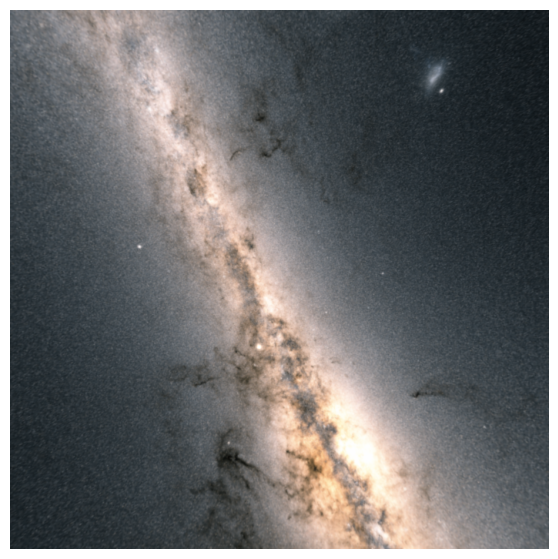

In [8]:
import matplotlib.pyplot as plt

def _enu_from_altaz(alt_deg, az_deg):
    alt = np.deg2rad(alt_deg)
    az  = np.deg2rad(az_deg)
    ca = np.cos(alt); sa = np.sin(alt)
    return np.stack([ca*np.sin(az), ca*np.cos(az), sa], axis=-1)  # (...,3)

def overlay_stars_on_bg(
    bg_rgb, stars_df,
    center_alt_deg=45, center_az_deg=180,
    fov_deg=80
):
    """
    bg_rgb: (N,N,3) float [0,1]
    stars_df needs: alt_deg, az_deg, mag
    """
    N = bg_rgb.shape[0]
    out = bg_rgb.copy()

    # basis
    alt0 = np.deg2rad(center_alt_deg)
    az0  = np.deg2rad(center_az_deg)

    def dir_from_altaz(alt, az):
        ca = np.cos(alt); sa = np.sin(alt)
        return np.array([ca*np.sin(az), ca*np.cos(az), sa], dtype=float)

    c = dir_from_altaz(alt0, az0)
    right = np.array([np.cos(alt0)*np.cos(az0), -np.cos(alt0)*np.sin(az0), 0.0])
    right = right / np.linalg.norm(right)
    up = np.array([-np.sin(alt0)*np.sin(az0), -np.sin(alt0)*np.cos(az0), np.cos(alt0)])
    up = up / np.linalg.norm(up)

    # star dirs ENU
    dirs = _enu_from_altaz(stars_df["alt_deg"].values, stars_df["az_deg"].values)  # (M,3)

    # gnomonic projection: x = dot(d,right)/dot(d,c), y = dot(d,up)/dot(d,c)
    denom = dirs @ c
    mask = denom > 0  # only within 90deg of center
    dirs = dirs[mask]
    mags = stars_df["mag"].values[mask]
    alts = stars_df["alt_deg"].values[mask]

    x = (dirs @ right) / denom[mask]
    y = (dirs @ up) / denom[mask]

    # map to pixel coords
    scale = np.tan(np.deg2rad(fov_deg)/2)
    px = (x/scale + 1) * 0.5 * (N-1)
    py = (1 - (y/scale + 1) * 0.5) * (N-1)  # y up -> pixel down

    # draw stars (simple glow)
    for (ix, iy, m, altv) in zip(px, py, mags, alts):
        ix = int(round(ix)); iy = int(round(iy))
        if ix < 0 or ix >= N or iy < 0 or iy >= N:
            continue

        # brightness model (simple): mag -> intensity, altitude -> dim near horizon
        alt_factor = np.clip(altv/90.0, 0.2, 1.0)
        intensity = alt_factor * 10**(-0.4*(m - (-1.0)))  # relative
        intensity = np.clip(intensity, 0.05, 1.0)

        # glow radius
        r = int(np.clip(2 + 6*intensity, 2, 8))
        for dy in range(-r, r+1):
            for dx in range(-r, r+1):
                x2 = ix+dx; y2 = iy+dy
                if x2 < 0 or x2 >= N or y2 < 0 or y2 >= N:
                    continue
                d2 = dx*dx + dy*dy
                w = np.exp(-d2/(2*(r/2)**2))
                out[y2, x2] = np.clip(out[y2, x2] + w*intensity*np.array([1,1,1]), 0, 1)

    return out

# 用你已经算好的 visible（含 alt_deg, az_deg, mag）
# 先选一个“视野中心”，比如朝南45°
bg_view = render_milkyway_background("milkyway.jpg", 42.28, -83.74, "2026-02-21 02:00:00",
                                     center_alt_deg=45, center_az_deg=180, fov_deg=90, out_size=700)
img = overlay_stars_on_bg(bg_view, visible, center_alt_deg=45, center_az_deg=180, fov_deg=90)
plt.figure(figsize=(7,7)); plt.imshow(img); plt.axis("off"); plt.show()

In [9]:
#def apply_light_pollution(img, strength=0.5):
    """
    strength: 0 = 完全黑暗乡村
              1 = 强光污染城市
    """
    h, w, _ = img.shape
    y = np.linspace(0, 1, h).reshape(-1,1)
    horizon_glow = np.exp(-3*y)  # 下方更亮

    glow = strength * 0.6 * horizon_glow
    glow = np.repeat(glow, w, axis=1)

    img_lp = img + glow[...,None]
    img_lp = np.clip(img_lp, 0, 1)

    # 降低对比度
    img_lp = img_lp*(1-strength*0.6) + strength*0.4

    return np.clip(img_lp, 0, 1)

IndentationError: unexpected indent (2317856303.py, line 2)

In [ ]:
#def apply_light_pollution(img, strength=0.5, sky_base=0.03):
    """
    strength: 0(暗) -> 1(亮)
    sky_base: 最暗天空底色（0.02~0.06之间调）
    """
    img = np.clip(img, 0, 1)
    h, w, _ = img.shape

    # 1) 地平线更亮（只在下方显著）
    y = np.linspace(0, 1, h).reshape(-1, 1)          # 0=上(天顶), 1=下(地平线)
    horizon = np.exp(-4*(1 - y))                      # 下方更强
    glow = strength * 0.25 * horizon                  # 0.25 可调
    glow = np.repeat(glow, w, axis=1)[..., None]

    # 2) 黑位抬高（天空本底亮度）
    base = sky_base + strength * 0.25                 # 0.25 可调（越大越亮）

    # 3) 压对比：把图往 base 收缩，而不是整体加白
    img_lp = base + (img - base) * (1 - 0.85*strength)

    # 4) 加地平线辉光
    img_lp = img_lp + glow

    return np.clip(img_lp, 0, 1)

In [20]:
def apply_light_pollution(img, strength=0.5):
    img = np.clip(img, 0, 1)
    h, w, _ = img.shape

    # 低空更亮（保留，但别太爆）
    y = np.linspace(0, 1, h).reshape(-1, 1)   # 0天顶, 1地平线
    horizon = np.exp(-4.5*(1 - y))
    glow = strength * 0.28 * horizon
    glow = np.repeat(glow, w, axis=1)[..., None]

    # 黑位抬高：这是“夜空底色”，别太高，否则像白天
    base = 0.015 + strength * 0.14

    # 对比压缩：城市会更平，但不要压到全糊
    img_lp = base + (img - base) * (1 - 0.70*strength)

    # 橙色天穹：强，但用“加色偏 + 限制亮度”的方式
    orange = np.array([1.0, 0.78, 0.55])[None, None, :]
    tint = strength * 0.45
    img_lp = img_lp*(1 - tint) + (img_lp * orange) * tint

    # 加地平线辉光
    img_lp += glow
    
    from scipy.ndimage import gaussian_filter
    blur_sigma = 4 * strength
    blurred = gaussian_filter(img_lp, sigma=(blur_sigma, blur_sigma, 0))
    img_lp = img_lp*(1 - 0.6*strength) + blurred*(0.6*strength)
    
    center = img_lp.mean(axis=(0,1), keepdims=True)
    img_lp = center + (img_lp - center) * (1 - 0.75*strength)
    
    return np.clip(img_lp, 0, 1)

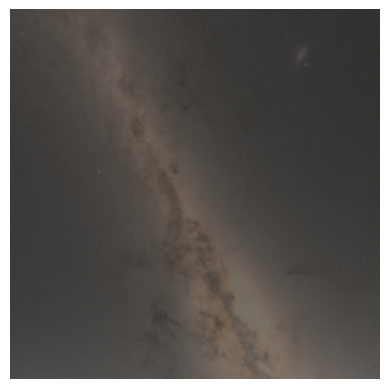

In [21]:
bg_lp = apply_light_pollution(bg_view, strength=0.7)

plt.imshow(bg_lp)
plt.axis("off")
plt.show()

In [22]:
import ipywidgets as widgets
from IPython.display import display

In [23]:
import pandas as pd
from astropy.coordinates import SkyCoord, AltAz
from astropy import units as u
from astropy.time import Time
from astropy.coordinates import EarthLocation

stars_df = pd.read_csv("stars.csv")

def compute_altaz(stars_df, lat_deg, lon_deg, dt_iso_utc):
    loc = EarthLocation(lat=lat_deg*u.deg, lon=lon_deg*u.deg, height=0*u.m)
    t = Time(dt_iso_utc)

    sc = SkyCoord(
        ra=stars_df["ra_deg"].values*u.deg,
        dec=stars_df["dec_deg"].values*u.deg,
        frame="icrs"
    )
    altaz = sc.transform_to(AltAz(obstime=t, location=loc))

    df = stars_df.copy()
    df["alt_deg"] = altaz.alt.deg
    df["az_deg"]  = altaz.az.deg
    df = df[df["alt_deg"] > 0].copy()
    df = df.sort_values("mag", ascending=True).reset_index(drop=True)
    return df

In [31]:
def apply_extinction(df, k=0.20):
    alt = np.clip(df["alt_deg"].values, 1, 90)
    X = 1.0 / np.sin(np.deg2rad(alt))
    df = df.copy()
    df["mag_obs"] = df["mag"].values + k * X
    return df

In [32]:
def tonwe_map(img, gamma=0.6):
    img = np.clip(img, 0, 1)
    return img ** gamma

In [33]:
def m_lim_from_lp(lp):
    return 7.0 - 4.8*lp   # lp=0 -> 7.0, lp=1 -> 2.2

In [34]:
import matplotlib.pyplot as plt

def render_frame(
    lat, lon, dt_iso_utc,
    center_alt, center_az, fov,
    light_pollution_strength,
    bg_path="milkyway.jpg",
    out_size=700
):
    # background
    bg = render_milkyway_background(
        bg_path, lat, lon, dt_iso_utc,
        center_alt_deg=center_alt,
        center_az_deg=center_az,
        fov_deg=fov,
        out_size=out_size
    )

    # apply light pollution (你已有函数)
    bg_lp = apply_light_pollution(bg, strength=light_pollution_strength)
    bg_lp = bg_lp * (1 - 0.75*light_pollution_strength) + 0.02*light_pollution_strength
    # stars
    vis = compute_altaz(stars_df, lat, lon, dt_iso_utc)
    vis = apply_extinction(vis, k=0.20)
    m_lim = m_lim_from_lp(light_pollution_strength)
    vis = vis[vis["mag_obs"] <= m_lim].copy()
    # overlay
    img = overlay_stars_on_bg(
        bg_lp, vis,
        center_alt_deg=center_alt,
        center_az_deg=center_az,
        fov_deg=fov
    )
    gamma = 0.55 + 0.35 * light_pollution_strength   # lp越高，gamma越接近0.9
    img = tone_map(img, gamma=gamma)
    plt.figure(figsize=(7,7))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [35]:
from ipywidgets import interact

LAT = 42.28
LON = -83.74
DT  = "2026-02-21 02:00:00"  # 先固定，下一步再做时间滑杆

@interact(
    center_az=(0, 359, 5),
    center_alt=(5, 85, 5),
    fov=(40, 120, 5),
    lp=(0.0, 1.0, 0.05)
)
def demo(center_az=180, center_alt=45, fov=90, lp=0.7):
    render_frame(
        LAT, LON, DT,
        center_alt, center_az, fov,
        lp,
        bg_path="milkyway.jpg",
        out_size=700
    )

interactive(children=(IntSlider(value=180, description='center_az', max=359, step=5), IntSlider(value=45, desc…

In [36]:
BASE_TIME = Time("2026-02-21 02:00:00")
from astropy.time import Time

@interact(
    hour_offset=(-6, 6, 0.5),
    center_az=(0, 359, 5),
    center_alt=(5, 85, 5),
    fov=(40, 120, 5),
    lp=(0.0, 1.0, 0.05)
)
def demo(hour_offset=0, center_az=180, center_alt=45, fov=90, lp=0.7):
    
    t = BASE_TIME + hour_offset * u.hour
    
    render_frame(
        LAT, LON, t.iso,
        center_alt, center_az, fov,
        lp,
        bg_path="milkyway.jpg",
        out_size=700
    )

interactive(children=(FloatSlider(value=0.0, description='hour_offset', max=6.0, min=-6.0, step=0.5), IntSlide…